# Machine Learning Capstone — Review 1
## Telescope Dataset — Classification Part A

This notebook implements the **Classification Part A** requirements for Review 1.

### Required algorithms
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine (SVM)

The workflow follows the project rubric:
**dataset audit → EDA → cleaning → feature engineering → stratified split → preprocessing → model training → comparison → evaluation → confusion matrices → tuning → cross-validation → conclusion.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load Dataset

The uploaded telescope dataset is read from the CSV file inside the provided ZIP archive.

In [2]:
import pandas as pd

DATA_PATH = "telescope_data.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset file:", DATA_PATH)
print("Shape:", df.shape)

display(df.head())

Dataset file: telescope_data.csv
Shape: (19020, 12)


,Unnamed: 0,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


## 2. Dataset Audit

The audit checks the dataset dimensions, data types, missing values, duplicates, unique values, and target distribution.

The `Unnamed: 0` column is an imported row/index identifier rather than a predictive measurement, so it will be removed before modelling. Keeping an index-like identifier could allow the model to learn ordering information instead of the actual telescope measurements.

In [3]:
print("Shape:", df.shape)

print("\nData Types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing Values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nUnique Values:")
display(df.nunique().to_frame("unique_count"))

print("\nTarget Distribution:")
display(df["class"].value_counts().to_frame("count"))

print("\nTarget Proportion:")
display(df["class"].value_counts(normalize=True).mul(100).round(2).to_frame("percentage"))

Shape: (19020, 12)

Data Types:


,dtype
Unnamed: 0,int64
fLength,float64
fWidth,float64
fSize,float64
fConc,float64
fConc1,float64
fAsym,float64
fM3Long,float64
fM3Trans,float64
fAlpha,float64



Missing Values:


,missing_count
Unnamed: 0,0
fLength,0
fWidth,0
fSize,0
fConc,0
fConc1,0
fAsym,0
fM3Long,0
fM3Trans,0
fAlpha,0



Duplicate Rows: 0

Unique Values:


,unique_count
Unnamed: 0,19020
fLength,18643
fWidth,18200
fSize,7228
fConc,6410
fConc1,4421
fAsym,18704
fM3Long,18693
fM3Trans,18390
fAlpha,17981



Target Distribution:


,count
class,
g,12332
h,6688



Target Proportion:


,percentage
class,
g,64.84
h,35.16


## 3. Target Distribution

This plot shows how many observations belong to each of the two classes, `g` and `h`.


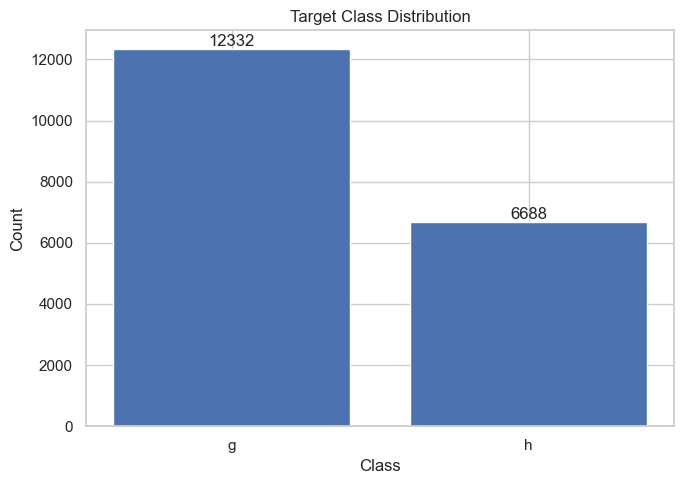

In [4]:
plt.figure(figsize=(7, 5))
counts = df["class"].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
for i, value in enumerate(counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")
plt.tight_layout()
plt.show()

### Observation

From the graph, I can see that class `g` has more observations than class `h`. There are about 12.3k `g` samples and 6.7k `h` samples, so the classes are not evenly balanced. This is why I used a stratified split later, so that the same class proportion is kept in both training and testing data.


## 4. Exploratory Data Analysis — Feature Distributions

The identifier column is excluded from the feature distributions because it is not a predictive measurement.

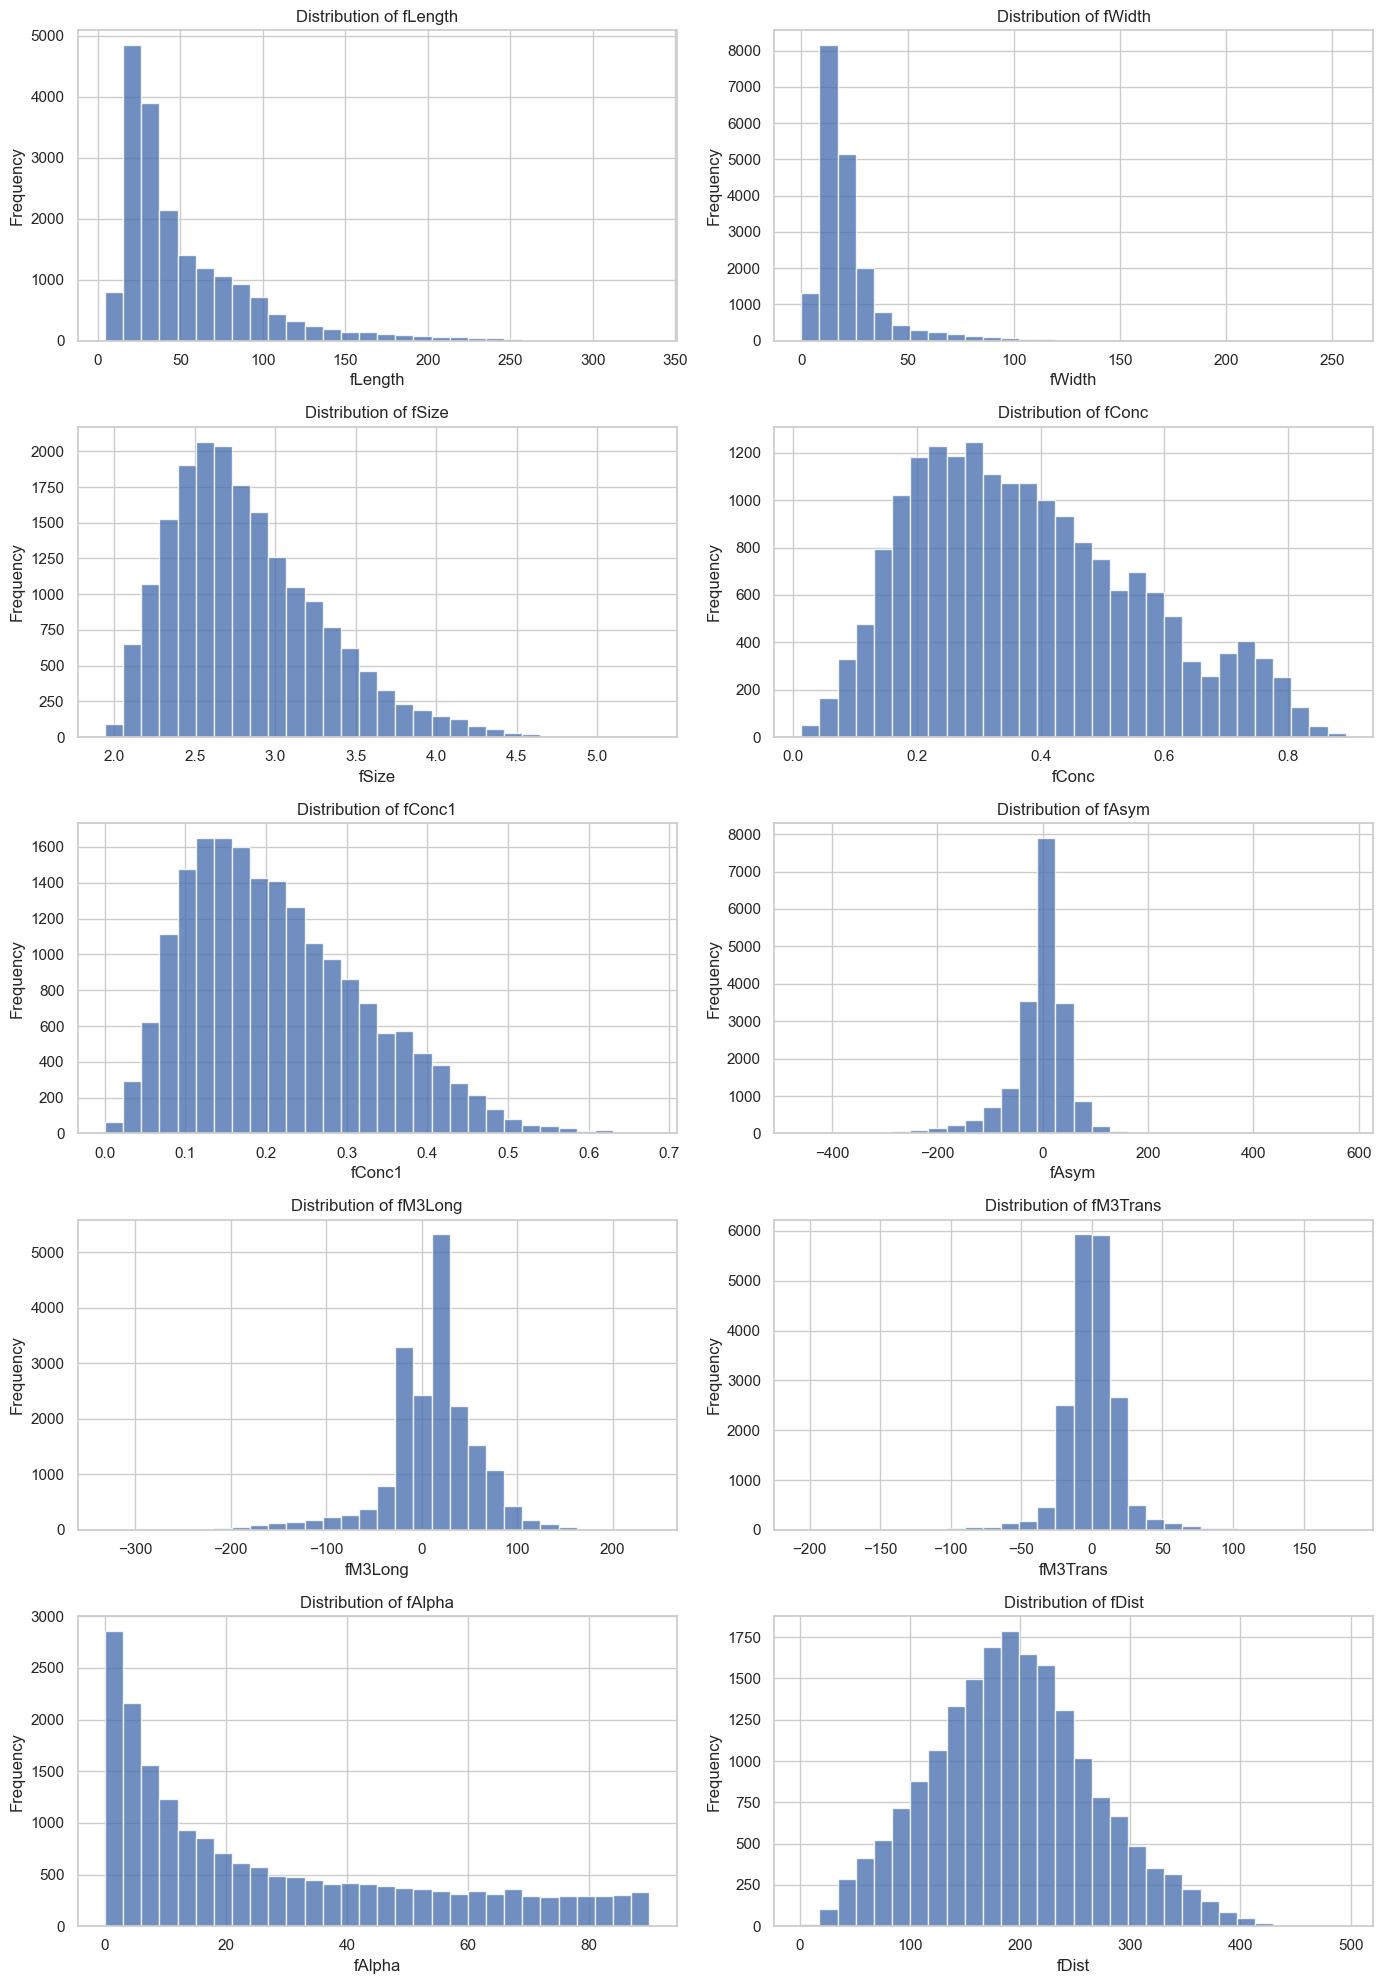

In [5]:
eda_features = [c for c in df.columns if c not in ["Unnamed: 0", "class"]]

n_cols = 2
n_rows = int(np.ceil(len(eda_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, feature in zip(axes, eda_features):
    ax.hist(df[feature], bins=30, alpha=0.8)
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

for ax in axes[len(eda_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

### EDA observations

Looking at the histograms, the features do not all have the same shape or range.

- `fLength` and `fWidth` are clearly right-skewed. Most values are on the lower side, with some much larger values.
- `fSize` is more concentrated around a smaller range, although it still has some higher values.
- `fConc` and `fConc1` have fairly similar distributions, which also makes sense because they measure related concentration values.
- `fAsym` and `fM3Long` spread out on both sides and have some very large positive and negative values.
- `fM3Trans` is more centered around zero compared with the other features.
- `fAlpha` has many smaller values but also extends up to around 90.
- `fDist` covers a wide range, so its scale is quite different from some of the other features.

Because the feature ranges are so different, scaling the data will be important for models such as KNN and SVM. The large tails in some of the histograms are also why I check the outliers before training the models.


## 5. Correlation Heatmap

The correlation matrix is used to inspect linear relationships among the numerical measurements.

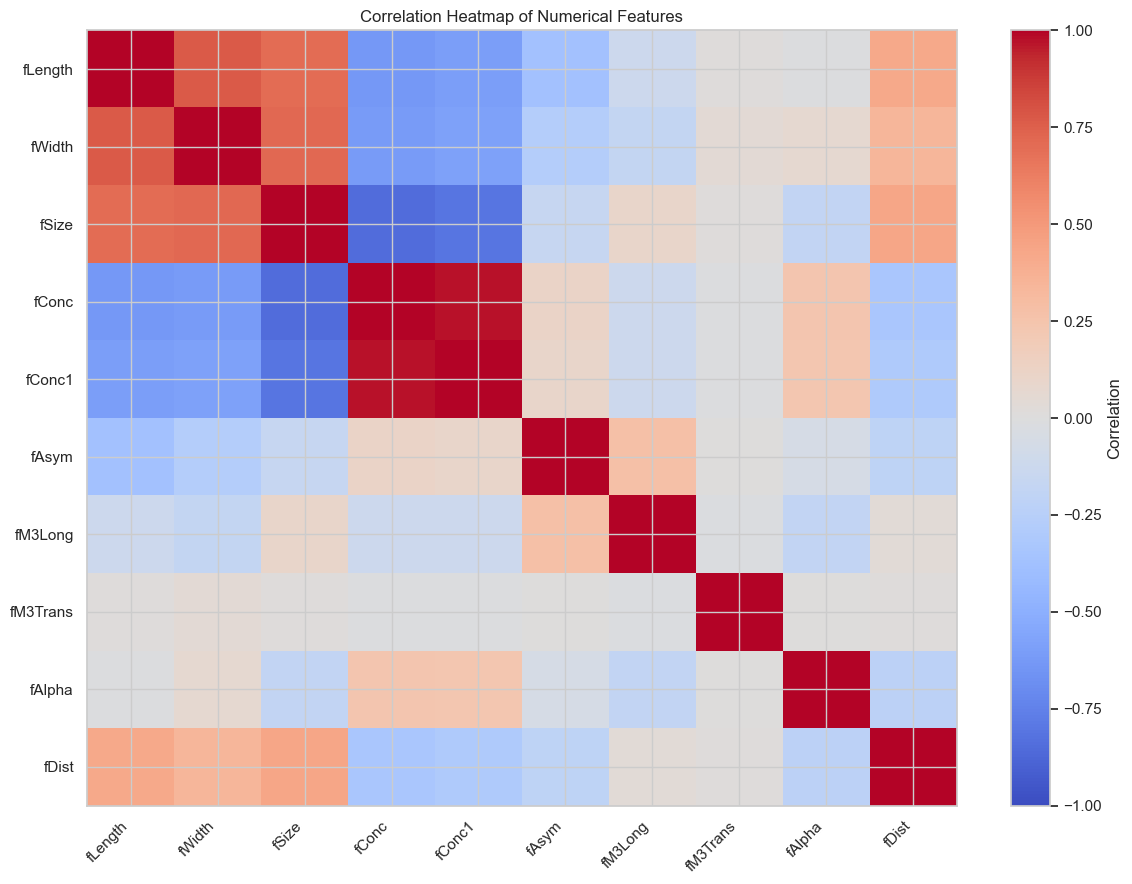

In [6]:
corr = df[eda_features].corr()

plt.figure(figsize=(12, 9))
plt.imshow(corr, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

### Correlation observation

The main thing I noticed in this heatmap is the very strong positive correlation between `fConc` and `fConc1` (about 0.98). They are measuring related things, so this result is not surprising.

I also noticed that `fConc` and `fSize` have a strong negative relationship, while `fLength` and `fWidth` have a fairly strong positive relationship. The rest of the features are more loosely related. So the features are not completely independent, and some of them contain similar information.


## 6. Feature–Target Relationships

Because the target is categorical, scatter plots use the target class as colour/hue. This allows the class distributions to be compared across individual numerical measurements.

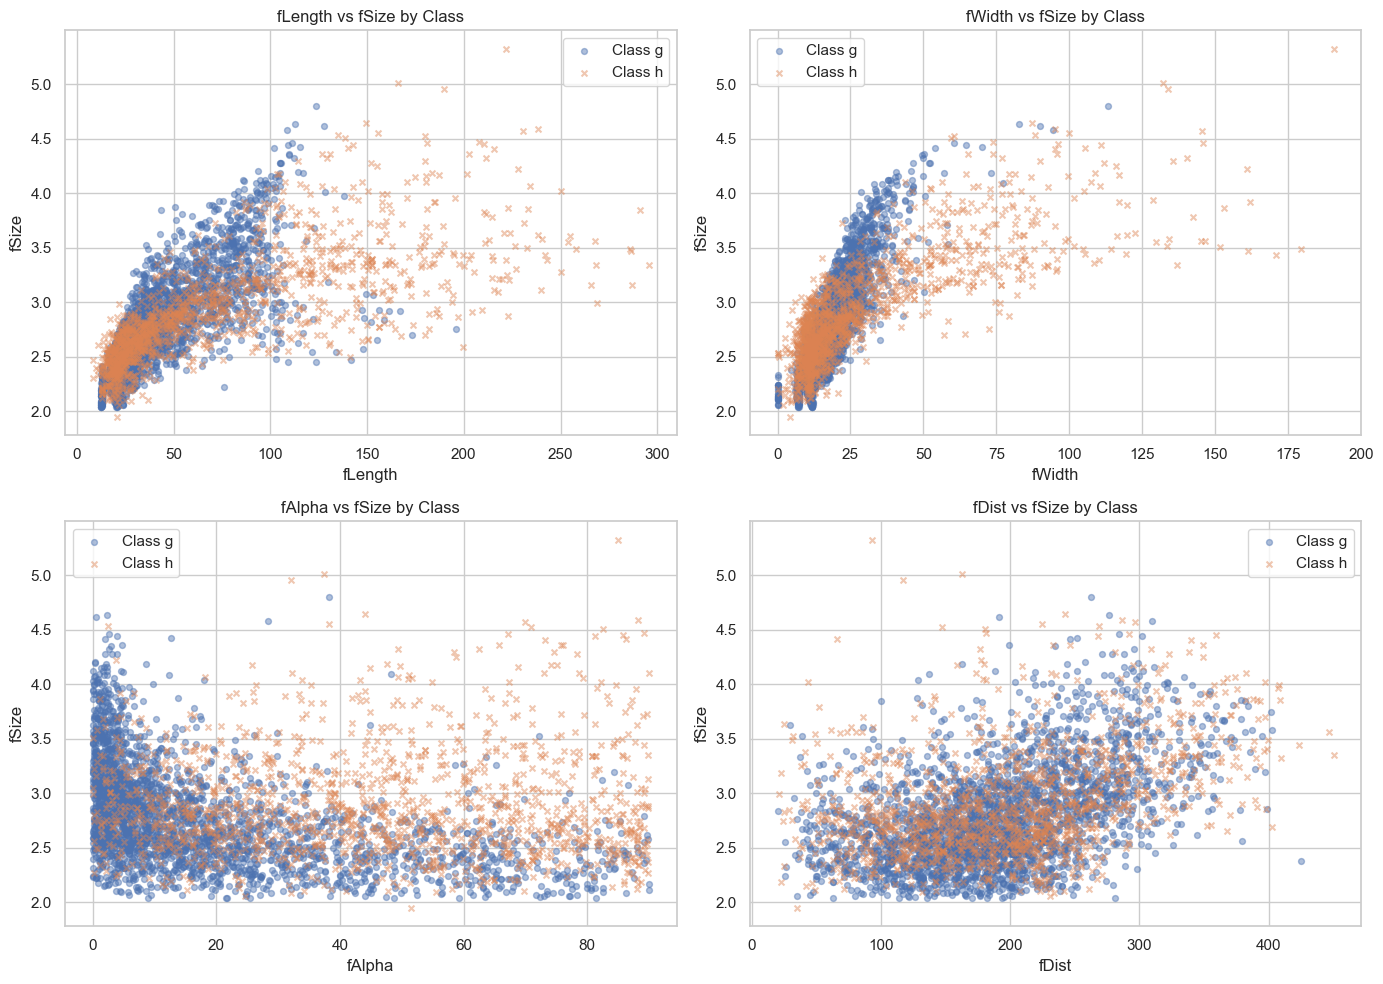

In [7]:
selected_scatter_features = ["fLength", "fWidth", "fAlpha", "fDist"]
sample_df = df.sample(min(4000, len(df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.ravel(), selected_scatter_features):
    for cls, marker in [("g", "o"), ("h", "x")]:
        subset = sample_df[sample_df["class"] == cls]
        ax.scatter(
            subset[feature], subset["fSize"],
            alpha=0.45, s=18, marker=marker, label=f"Class {cls}"
        )
    ax.set_title(f"{feature} vs fSize by Class")
    ax.set_xlabel(feature)
    ax.set_ylabel("fSize")
    ax.legend()

plt.tight_layout()
plt.show()

### Feature–target observations

I can see some difference between the two classes in these plots, but the points still overlap quite a lot.

- For `fLength` vs `fSize`, class `h` generally appears at larger `fLength` values than class `g`.
- `fWidth` shows a similar pattern. The `h` points tend to extend further to the right, although there is still a lot of overlap.
- `fAlpha` shows a clearer difference between the classes. The `h` class has noticeably higher values on average.
- For `fDist`, the two classes overlap more, so it does not look as useful by itself for separating them.

Overall, these plots make it clear that using several features together should work better than trying to classify the samples using just one feature.


### Additional feature–target scatter plots

Since `class` is categorical, the target is represented on the y-axis as 0/1 with a small deterministic jitter. This makes the required feature–target scatter relationship explicit while keeping the original EDA plots unchanged.


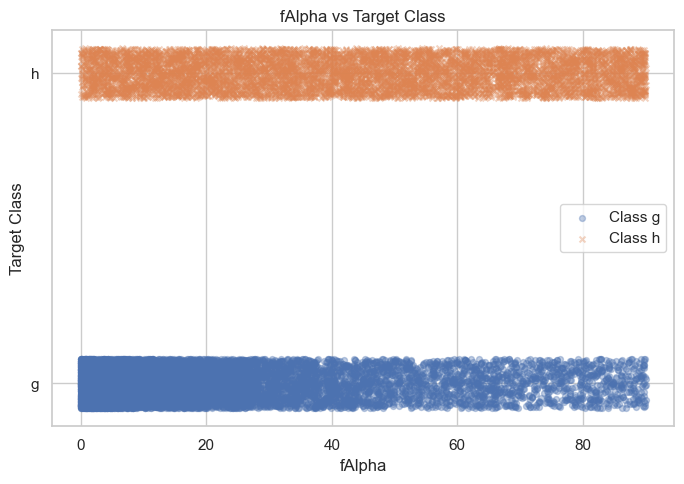

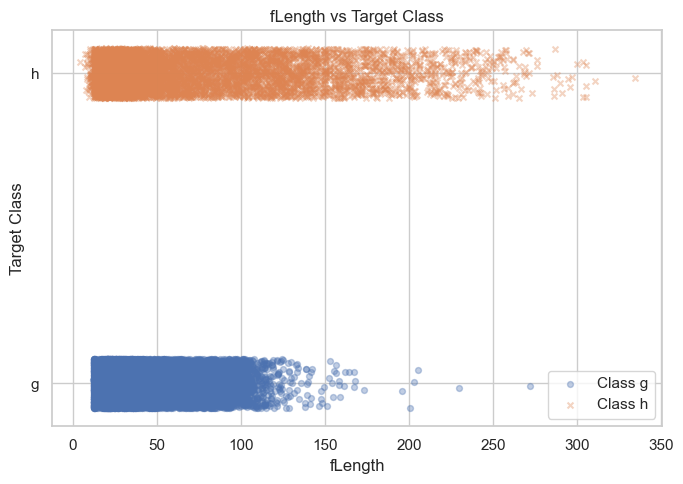

In [8]:
# Explicit feature–target scatter plots for the categorical target
plot_df = df[["fAlpha", "fLength", "class"]].dropna().copy()
plot_df["class_numeric"] = plot_df["class"].map({"g": 0, "h": 1})
rng = np.random.RandomState(RANDOM_STATE)
plot_df["class_jitter"] = plot_df["class_numeric"] + rng.uniform(-0.08, 0.08, size=len(plot_df))

for feature in ["fAlpha", "fLength"]:
    plt.figure(figsize=(7, 5))
    for cls, marker in [("g", "o"), ("h", "x")]:
        subset = plot_df[plot_df["class"] == cls]
        plt.scatter(
            subset[feature],
            subset["class_jitter"],
            alpha=0.35,
            s=18,
            marker=marker,
            label=f"Class {cls}"
        )
    plt.yticks([0, 1], ["g", "h"])
    plt.title(f"{feature} vs Target Class")
    plt.xlabel(feature)
    plt.ylabel("Target Class")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 7. Feature Engineering

A new feature, `fConcDiff`, is created as:

**fConcDiff = fConc − fConc1**

### Justification

`fConc` and `fConc1` represent two related concentration measurements. Their difference captures how far the two concentration measures are separated, providing a compact derived signal that is not directly represented by either feature alone.

In [9]:
df_model = df.copy()

df_model["fConcDiff"] = df_model["fConc"] - df_model["fConc1"]

print("New feature created: fConcDiff")
display(df_model[["fConc", "fConc1", "fConcDiff"]].head())

print("\nCorrelation of engineered feature with original numerical features:")
display(
    df_model.drop(columns=["Unnamed: 0", "class"]).corr()["fConcDiff"]
    .sort_values(ascending=False)
    .to_frame("correlation")
)

New feature created: fConcDiff


,fConc,fConc1,fConcDiff
0,0.3918,0.1982,0.1936
1,0.5303,0.3773,0.1530
2,0.0374,0.0187,0.0187
3,0.6147,0.3922,0.2225
4,0.3168,0.1832,0.1336



Correlation of engineered feature with original numerical features:


,correlation
fConcDiff,1.000000
fConc,0.952829
fConc1,0.864821
fAlpha,0.224067
fAsym,0.120281
fM3Trans,-0.010849
fM3Long,-0.116508
fDist,-0.335283
fWidth,-0.601052
fLength,-0.626494


## 8. Outlier Inspection

Outliers are checked using the IQR rule. The inspection is performed before modelling so that unusually large measurements can be treated without deleting potentially informative telescope events.

In [10]:
outlier_rows = []

for feature in [c for c in df_model.columns if c not in ["Unnamed: 0", "class"]]:
    q1 = df_model[feature].quantile(0.25)
    q3 = df_model[feature].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df_model[feature] < lower) | (df_model[feature] > upper)).sum()

    outlier_rows.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": int(count)
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values(
    "Outlier Count", ascending=False
).reset_index(drop=True)

display(outlier_df)

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
0,fAsym,-20.586550,24.063700,-87.561925,91.039075,1781
1,fWidth,11.863800,24.739475,-7.449712,44.052988,1546
2,fM3Long,-12.842775,35.837800,-85.863638,108.858663,1218
3,fLength,24.336000,70.122175,-44.343262,138.801437,971
4,fM3Trans,-10.849375,10.946425,-43.543075,43.640125,850
5,fSize,2.477100,3.101600,1.540350,4.038350,367
6,fConc1,0.128475,0.285225,-0.106650,0.520350,150
7,fDist,142.492250,240.563825,-4.615112,387.671187,128
8,fConcDiff,0.104700,0.216800,-0.063450,0.384950,55
9,fConc,0.235800,0.503700,-0.166050,0.905550,0


### Outlier treatment

I found quite a few extreme values in some of the features, especially `fLength`, `fWidth`, `fAsym`, and `fM3Long`. I did not want to simply delete all of those rows because they are still real observations in the dataset.

Instead, I used IQR-based clipping inside the preprocessing pipeline. The limits are learned from the training data only, and the same limits are then applied to the test data. This keeps the extreme values from dominating the models without throwing away the samples.


# PART I — CLASSIFICATION PART A

The five algorithms required for Review 1 are:
1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine

## 9. Prepare Classification Dataset

The identifier column is removed because it represents row order rather than a measurement. The target column `class` is separated from the predictors.

In [11]:
classification_df = df_model.copy()

X_cls = classification_df.drop(["class", "Unnamed: 0"], axis=1)
y_cls = classification_df["class"]

print("X shape:", X_cls.shape)
print("y shape:", y_cls.shape)

print("\nFeature columns:")
print(list(X_cls.columns))

print("\nClass Distribution:")
display(y_cls.value_counts().to_frame("count"))

X shape: (19020, 11)
y shape: (19020,)

Feature columns:
['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'fConcDiff']

Class Distribution:


,count
class,
g,12332
h,6688


## 10. Stratified Classification Train/Test Split

An 80:20 split is used with `stratify=y_cls` so that both classes maintain approximately the same proportions in the training and test sets.

In [12]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_cls
)

print("Training:", X_train_cls.shape)
print("Testing:", X_test_cls.shape)

print("\nTraining class proportions:")
display(y_train_cls.value_counts(normalize=True).mul(100).round(2).to_frame("percentage"))

print("\nTesting class proportions:")
display(y_test_cls.value_counts(normalize=True).mul(100).round(2).to_frame("percentage"))

Training: (15216, 11)
Testing: (3804, 11)

Training class proportions:


,percentage
class,
g,64.84
h,35.16



Testing class proportions:


,percentage
class,
g,64.83
h,35.17


## 11. Classification Preprocessing

All predictors are numerical, so no categorical encoder is required.

The preprocessing pipeline performs:
- median imputation for robustness,
- training-set IQR clipping,
- StandardScaler.

The preprocessing is placed inside each model pipeline so that the transformation is fitted only on the training data. This prevents test-set information from leaking into model training.

In [13]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        q1 = X_df.quantile(0.25)
        q3 = X_df.quantile(0.75)
        iqr = q3 - q1

        self.lower_ = (q1 - 1.5 * iqr).to_numpy()
        self.upper_ = (q3 + 1.5 * iqr).to_numpy()
        return self

    def transform(self, X):
        X_array = np.asarray(X, dtype=float)
        return np.clip(X_array, self.lower_, self.upper_)

classification_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clipper", IQRClipper()),
        ("scaler", StandardScaler())
    ]
)

print("Categorical features: []")
print("Numerical features:", list(X_cls.columns))

Categorical features: []
Numerical features: ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'fConcDiff']


## 12. Define Classification Part-A Models

The five required Review 1 algorithms are defined with reproducible settings.

In [14]:
classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "SVM": SVC(
        kernel="rbf",
        C=1,
        probability=False,
        random_state=RANDOM_STATE
    )
}

display(pd.DataFrame({
    "Model": list(classification_models.keys()),
    "Configuration": [str(model) for model in classification_models.values()]
}))

,Model,Configuration
0,Logistic Regression,"LogisticRegression(max_iter=2000, random_state..."
1,KNN,KNeighborsClassifier()
2,Naive Bayes,GaussianNB()
3,Decision Tree,DecisionTreeClassifier(random_state=42)
4,SVM,"SVC(C=1, random_state=42)"


## 13. Train All Classification Part-A Models

All five algorithms use the **same training/test split** and the same preprocessing approach. Accuracy, weighted precision, weighted recall, weighted F1-score, and ROC-AUC are calculated.

In [15]:
classification_results = []
trained_classification_models = {}

for name, model in classification_models.items():

    print(f"Training {name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", classification_preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train_cls, y_train_cls)

    predictions = pipeline.predict(X_test_cls)

    accuracy = accuracy_score(y_test_cls, predictions)
    precision = precision_score(
        y_test_cls, predictions,
        average="weighted", zero_division=0
    )
    recall = recall_score(
        y_test_cls, predictions,
        average="weighted", zero_division=0
    )
    f1 = f1_score(
        y_test_cls, predictions,
        average="weighted", zero_division=0
    )

    classes = list(pipeline.named_steps["model"].classes_)
    positive_class = "g"
    positive_index = classes.index(positive_class)

    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        probabilities = pipeline.predict_proba(X_test_cls)[:, positive_index]
    else:
        probabilities = pipeline.decision_function(X_test_cls)
        # SVC decision scores correspond to classes_[1]. Reverse the sign
        # when the chosen positive class is classes_[0].
        if classes[1] != positive_class:
            probabilities = -probabilities

    y_test_binary = (y_test_cls == positive_class).astype(int)
    roc_auc = roc_auc_score(y_test_binary, probabilities)

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    trained_classification_models[name] = pipeline

classification_results_df = pd.DataFrame(classification_results)

classification_results_df = (
    classification_results_df
    .sort_values(by="F1 Score", ascending=False)
    .reset_index(drop=True)
)

display(classification_results_df.round(4))

Training Logistic Regression...
Training KNN...
Training Naive Bayes...
Training Decision Tree...
Training SVM...


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.8796,0.8825,0.8796,0.8761,0.9256
1,KNN,0.8425,0.8464,0.8425,0.8359,0.8832
2,Decision Tree,0.8207,0.8208,0.8207,0.8208,0.8038
3,Logistic Regression,0.8049,0.8026,0.8049,0.7988,0.8462
4,Naive Bayes,0.7237,0.7142,0.7237,0.7134,0.7577


### Initial model comparison observation

From the comparison table, SVM has the highest scores among the five baseline models, while Naive Bayes is noticeably lower. KNN is the next strongest model after SVM.

The classes are not perfectly balanced, so I am also looking at weighted F1 along with accuracy instead of judging the models from accuracy alone. The ROC-AUC values also give another way to compare how well the models separate the two classes.


## 14. Classification Reports

A detailed classification report is displayed for every required algorithm.

In [16]:
for name, model in trained_classification_models.items():

    predictions = model.predict(X_test_cls)

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test_cls,
            predictions,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

           g       0.81      0.91      0.86      2466
           h       0.78      0.62      0.69      1338

    accuracy                           0.80      3804
   macro avg       0.80      0.76      0.77      3804
weighted avg       0.80      0.80      0.80      3804

KNN
              precision    recall  f1-score   support

           g       0.83      0.95      0.89      2466
           h       0.87      0.65      0.74      1338

    accuracy                           0.84      3804
   macro avg       0.85      0.80      0.81      3804
weighted avg       0.85      0.84      0.84      3804

Naive Bayes
              precision    recall  f1-score   support

           g       0.75      0.85      0.80      2466
           h       0.64      0.49      0.55      1338

    accuracy                           0.72      3804
   macro avg       0.70      0.67      0.68      3804
weighted avg       0.71      0.72     

              precision    recall  f1-score   support

           g       0.75      0.85      0.80      2466
           h       0.64      0.49      0.55      1338

    accuracy                           0.72      3804
   macro avg       0.70      0.67      0.68      3804
weighted avg       0.71      0.72      0.71      3804

Decision Tree
              precision    recall  f1-score   support

           g       0.86      0.86      0.86      2466
           h       0.74      0.75      0.75      1338

    accuracy                           0.82      3804
   macro avg       0.80      0.80      0.80      3804
weighted avg       0.82      0.82      0.82      3804



SVM
              precision    recall  f1-score   support

           g       0.87      0.96      0.91      2466
           h       0.91      0.73      0.81      1338

    accuracy                           0.88      3804
   macro avg       0.89      0.85      0.86      3804
weighted avg       0.88      0.88      0.88      3804



## 15. Confusion Matrices

Confusion matrices show the number of correct and incorrect predictions for each class.

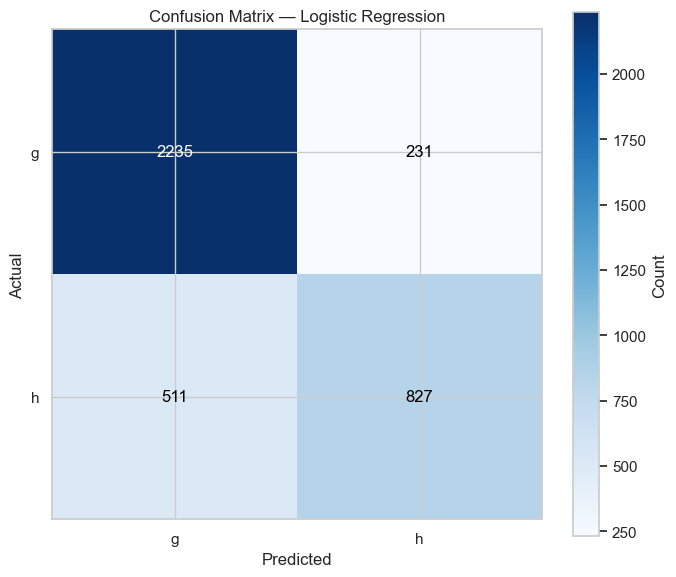

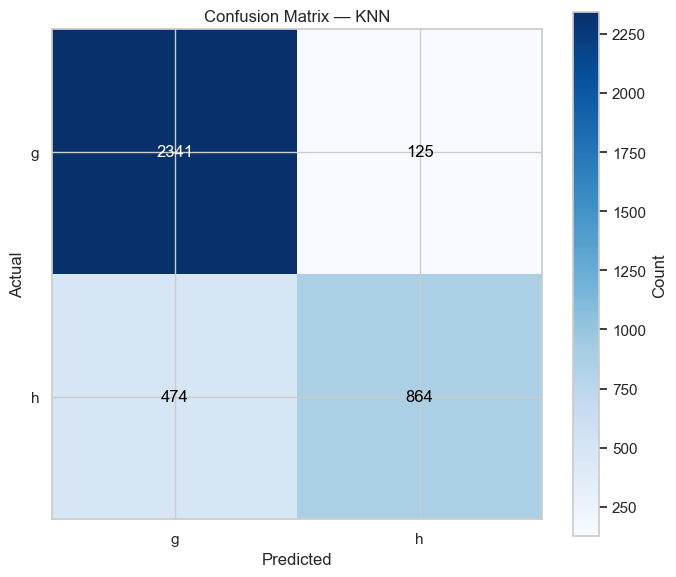

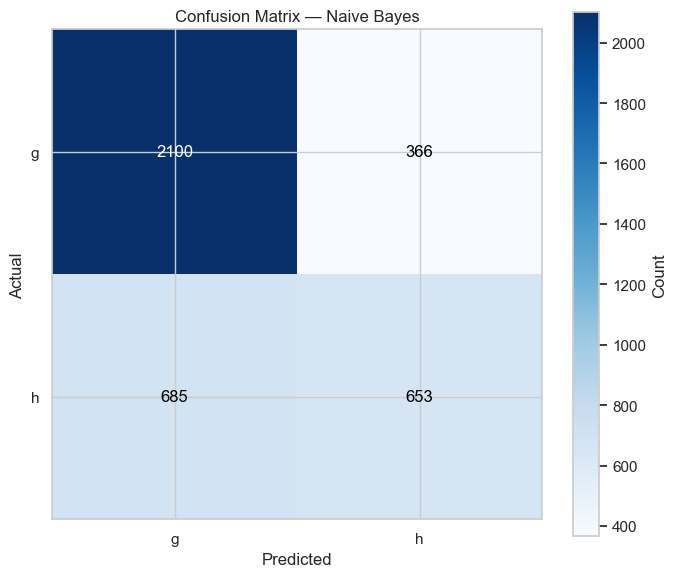

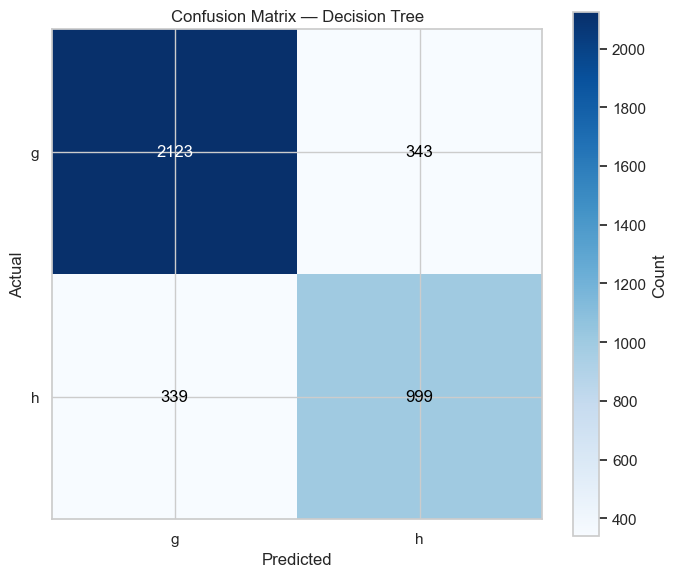

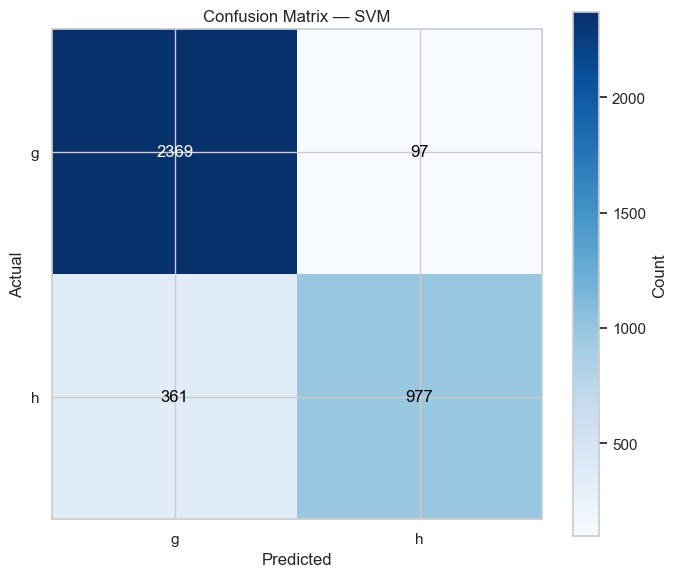

In [17]:
for name, model in trained_classification_models.items():

    predictions = model.predict(X_test_cls)

    cm = confusion_matrix(
        y_test_cls,
        predictions,
        labels=model.classes_
    )

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.colorbar(label="Count")
    tick_marks = np.arange(len(model.classes_))
    plt.xticks(tick_marks, model.classes_)
    plt.yticks(tick_marks, model.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    threshold = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > threshold else "black"
            )

    plt.tight_layout()
    plt.show()

### Confusion-matrix observations

I looked at each matrix separately because the total accuracy does not show which class is being misclassified.

- **Logistic Regression:** It correctly identifies most `g` samples, but it misses quite a few `h` samples. There are 511 `h` samples predicted as `g`.
- **KNN:** It improves on Logistic Regression for both classes. It still misses 474 `h` samples, but it only predicts 125 `g` samples as `h`.
- **Naive Bayes:** This has the largest number of `h` samples predicted as `g` (685), which matches its lower recall and F1 for class `h`.
- **Decision Tree:** The errors are more balanced between the two classes, with 343 `g` samples predicted as `h` and 339 `h` samples predicted as `g`.
- **SVM:** This has the fewest errors overall. It correctly classifies 2369 `g` samples and 977 `h` samples, although `h` is still the harder class because 361 of them are predicted as `g`.

So the confusion matrices also support what I saw in the comparison table: SVM is the strongest baseline model, while class `h` is generally harder for all five models.


## 16. Hyperparameter Tuning — KNN

KNN performance depends on the number of neighbours and the weighting strategy. GridSearchCV is used to compare several values of `k` and both uniform and distance-based weighting.

In [18]:
knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", classification_preprocessor),
        ("model", KNeighborsClassifier())
    ]
)

knn_params = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_params,
    cv=3,
    scoring="f1_weighted",
    n_jobs=1
)

knn_grid.fit(X_train_cls, y_train_cls)

knn_baseline = trained_classification_models["KNN"]
knn_base_pred = knn_baseline.predict(X_test_cls)
knn_base_f1 = f1_score(
    y_test_cls, knn_base_pred,
    average="weighted", zero_division=0
)

knn_tuned_pred = knn_grid.predict(X_test_cls)
knn_tuned_f1 = f1_score(
    y_test_cls, knn_tuned_pred,
    average="weighted", zero_division=0
)

print("KNN best parameters:", knn_grid.best_params_)
print(f"KNN baseline test weighted F1: {knn_base_f1:.6f}")
print(f"KNN tuned test weighted F1:    {knn_tuned_f1:.6f}")
print(f"Test improvement:              {knn_tuned_f1 - knn_base_f1:+.6f}")
print(f"Best CV weighted F1:            {knn_grid.best_score_:.6f}")

KNN best parameters: {'model__n_neighbors': 5, 'model__weights': 'distance'}
KNN baseline test weighted F1: 0.835929
KNN tuned test weighted F1:    0.841492
Test improvement:              +0.005563
Best CV weighted F1:            0.825444


## 17. Hyperparameter Tuning — Decision Tree

The Decision Tree algorithm is tuned using `max_depth` and `min_samples_leaf`. This controls tree complexity and helps reduce overfitting.

In [19]:
tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", classification_preprocessor),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

tree_params = {
    "model__max_depth": [5, 10, 15, 20, None],
    "model__min_samples_leaf": [1, 2, 5]
}

tree_grid = GridSearchCV(
    tree_pipeline,
    tree_params,
    cv=3,
    scoring="f1_weighted",
    n_jobs=1
)

tree_grid.fit(X_train_cls, y_train_cls)

tree_baseline = trained_classification_models["Decision Tree"]
tree_base_pred = tree_baseline.predict(X_test_cls)
tree_base_f1 = f1_score(
    y_test_cls, tree_base_pred,
    average="weighted", zero_division=0
)

tree_tuned_pred = tree_grid.predict(X_test_cls)
tree_tuned_f1 = f1_score(
    y_test_cls, tree_tuned_pred,
    average="weighted", zero_division=0
)

print("Decision Tree best parameters:", tree_grid.best_params_)
print(f"Decision Tree baseline test weighted F1: {tree_base_f1:.6f}")
print(f"Decision Tree tuned test weighted F1:    {tree_tuned_f1:.6f}")
print(f"Test improvement:                       {tree_tuned_f1 - tree_base_f1:+.6f}")
print(f"Best CV weighted F1:                    {tree_grid.best_score_:.6f}")

Decision Tree best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 2}
Decision Tree baseline test weighted F1: 0.820776
Decision Tree tuned test weighted F1:    0.843932
Test improvement:                       +0.023156
Best CV weighted F1:                    0.832754


## 18. 5-Fold Cross-Validation for the Two Best Baseline Models

The initial comparison identifies SVM and KNN as the two strongest baseline models by weighted F1. Five-fold cross-validation is therefore used to estimate how consistently these models perform across different training folds.

In [20]:
cv_models = {
    "SVM": trained_classification_models["SVM"],
    "KNN": trained_classification_models["KNN"]
}

cv_results = []

for name, model in cv_models.items():

    scores = cross_val_score(
        model,
        X_train_cls,
        y_train_cls,
        cv=5,
        scoring="f1_weighted",
        n_jobs=1
    )

    cv_results.append({
        "Model": name,
        "Mean CV Weighted F1": scores.mean(),
        "Std CV Weighted F1": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df.round(4))

,Model,Mean CV Weighted F1,Std CV Weighted F1
0,SVM,0.8636,0.0065
1,KNN,0.8238,0.0057


## 19. Final Classification Results

The table below is the main Review 1 comparison for the five required Part-A algorithms.

In [21]:
display(classification_results_df.round(4))

print("\nTUNING SUMMARY")
tuning_summary = pd.DataFrame([
    {
        "Model": "KNN",
        "Best Parameters": str(knn_grid.best_params_),
        "Baseline F1": knn_base_f1,
        "Tuned F1": knn_tuned_f1,
        "Improvement": knn_tuned_f1 - knn_base_f1
    },
    {
        "Model": "Decision Tree",
        "Best Parameters": str(tree_grid.best_params_),
        "Baseline F1": tree_base_f1,
        "Tuned F1": tree_tuned_f1,
        "Improvement": tree_tuned_f1 - tree_base_f1
    }
])

display(tuning_summary.round(6))

print("\n5-FOLD CROSS-VALIDATION")
display(cv_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.8796,0.8825,0.8796,0.8761,0.9256
1,KNN,0.8425,0.8464,0.8425,0.8359,0.8832
2,Decision Tree,0.8207,0.8208,0.8207,0.8208,0.8038
3,Logistic Regression,0.8049,0.8026,0.8049,0.7988,0.8462
4,Naive Bayes,0.7237,0.7142,0.7237,0.7134,0.7577



TUNING SUMMARY


,Model,Best Parameters,Baseline F1,Tuned F1,Improvement
0,KNN,"{'model__n_neighbors': 5, 'model__weights': 'd...",0.835929,0.841492,0.005563
1,Decision Tree,"{'model__max_depth': 10, 'model__min_samples_l...",0.820776,0.843932,0.023156



5-FOLD CROSS-VALIDATION


,Model,Mean CV Weighted F1,Std CV Weighted F1
0,SVM,0.8636,0.0065
1,KNN,0.8238,0.0057


# Review 1 Conclusion

## Classification

I trained the five classification algorithms required for Review 1 using the same stratified 80:20 train/test split. I compared them using accuracy, precision, recall, weighted F1-score and ROC-AUC, and I used confusion matrices to see where the models were making mistakes.

From the baseline results, SVM performs the best overall. KNN is the next strongest model, while Naive Bayes gives the lowest scores among the five.

I also tuned KNN and Decision Tree using GridSearchCV. The tuning results are shown in the final table, including the change in weighted F1-score.

Finally, I used 5-fold cross-validation on the two strongest baseline models to check whether their performance is consistent across different training folds.

The main thing I noticed from the whole analysis is that class `h` is harder to predict than class `g` for most of the models. Using preprocessing and scaling also makes a clear difference for models such as KNN and SVM.
